#  Stock Forecasting

**Goal:** Build a time series forecasting model (RNN/LSTM) to predict future stock values and visualize predicted vs actual results.

**Dataset:** Small stock price

**Tools:** Python, Pandas, Numpy, Matplotlib, TensorFlow/Keras

## 1️⃣ Load and Explore Dataset

- Dataset should have at least one feature: **Close price**
- Visualize the dataset to understand trends and patterns.

In [52]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/sample_stock.csv.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df.head()

/tmp/ipykernel_439/3004295488.py:5: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


,Open,High,Low,Close,Volume
Date,,,,,
1980-12-12 00:00:00-05:00,0.098834,0.099264,0.098834,0.098834,469033600
1980-12-15 00:00:00-05:00,0.094108,0.094108,0.093678,0.093678,175884800
1980-12-16 00:00:00-05:00,0.087232,0.087232,0.086802,0.086802,105728000
1980-12-17 00:00:00-05:00,0.088951,0.089381,0.088951,0.088951,86441600
1980-12-18 00:00:00-05:00,0.091530,0.091959,0.091530,0.091530,73449600


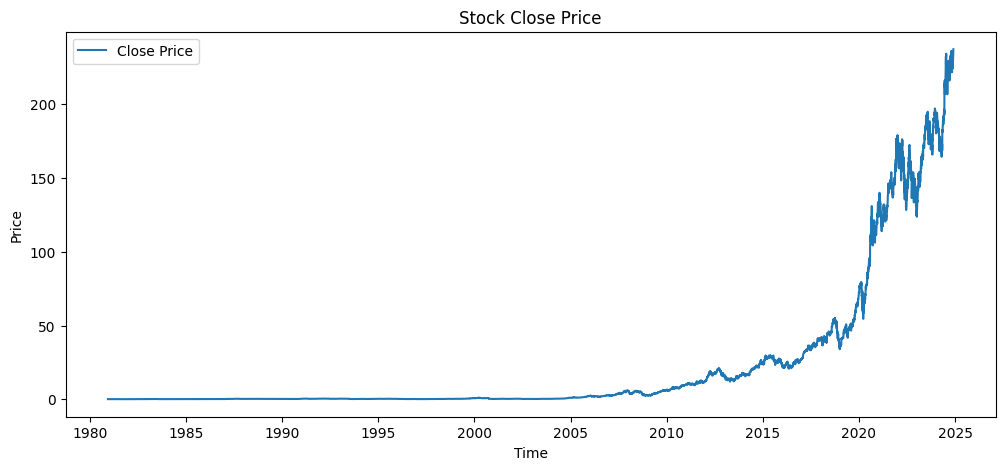

In [53]:
import matplotlib.pyplot as plt
# Plot target feature
plt.figure(figsize=(12,5))
plt.plot(df["Close"], label="Close Price")
plt.title("Stock Close Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## 2️⃣ Prepare Time Series Sequences

- Convert time series into supervised learning format:
    - Input X → past `sequence_length` timesteps
    - Output y → next timestep value
- Reshape data for LSTM: `(samples, timesteps, features)`

In [54]:
import numpy as np

# Extract target values
data = df["Close"].values # Make sure 'Close' column exists in the CSV

sequence_length = 5  # Number of past steps to use

X = []
y = []

for i in range(len(data) - sequence_length):
    X.append(data[i:i+sequence_length])
    y.append(data[i+sequence_length])

X = np.array(X)
y = np.array(y)

# Reshape for RNN/LSTM: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (11079, 5, 1)
Shape of y: (11079,)


## 3️⃣ Train/Test Split

- Split dataset into **80% training** and **20% testing**.
- Training data → model learns patterns.
- Testing data → evaluate predictions.

In [55]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Train samples: 8863
Test samples: 2216


## 4️⃣ Build LSTM Model

- LSTM is preferred for time series due to ability to remember long-term dependencies.
- Model architecture:
    - 1 LSTM layer with 50 units
    - Dense output layer with 1 unit
- Optimizer: Adam
- Loss: MSE

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation="relu", input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## 5️⃣ Train LSTM Model

- Train with small batch size (16) for better generalization on small dataset.
- Use moderate epochs (50) for a balance of training time and performance.

In [57]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 8.0020 - val_loss: 59.4877
Epoch 2/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0559 - val_loss: 39.8794
Epoch 3/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0494 - val_loss: 22.9696
Epoch 4/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0472 - val_loss: 13.5117
Epoch 5/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0449 - val_loss: 8.0618
Epoch 6/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0337 - val_loss: 94.9119
Epoch 7/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0353 - val_loss: 62.8753
Epoch 8/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0471 - val_loss: 13.4752
Epoch 9/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0278 - val_loss: 90.3487
Epoch 10/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0277 - val_loss: 71.6262
Epoch 11/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0283 - val_loss: 15.0873
Epoch 12/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 3

## 6️⃣ Training & Validation Loss
- Visualize loss curve to check for convergence.

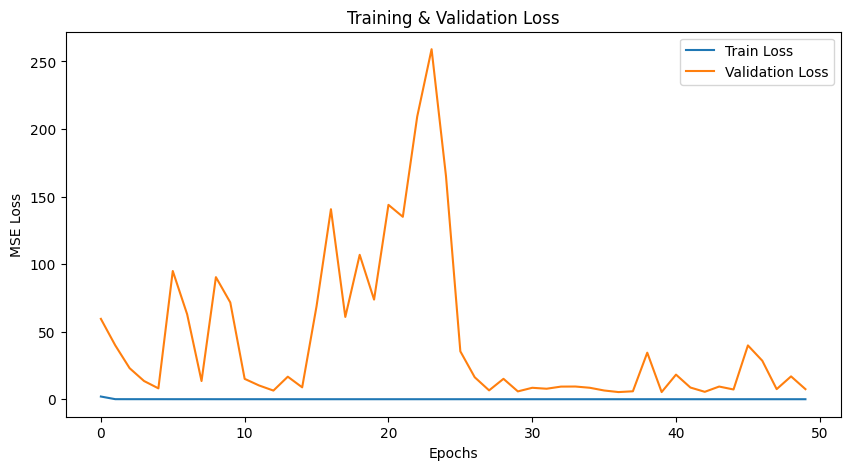

In [58]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

## 7️⃣ Predict Future Values
- Predict on test set
- Compare predicted vs actual values

In [59]:
y_pred = model.predict(X_test)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


## 8️⃣ Visualize Predictions vs Actual
- Plot predicted values vs actual test values to evaluate performance visually.

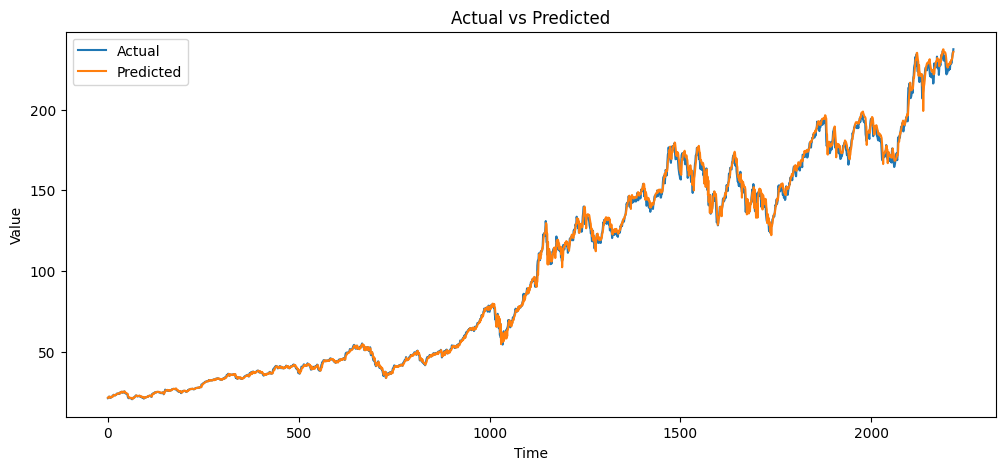

In [60]:
plt.figure(figsize=(12,5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

## 9️⃣ Model Evaluation Metrics
- RMSE: Root Mean Squared Error
- MAE: Mean Absolute Error
- Lower values indicate better performance

In [61]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.735339116757426
MAE: 1.7390581538253602


## ✅ Conclusion

- Successfully built a **LSTM forecasting model**.
- Model predicts future stock values based on past data.
- Evaluated using **RMSE & MAE**.
- Visualizations show how well the model follows the trend.
